# Process Energy Demand Modelling — Debug Notebook

Step-by-step pipeline for interactive debugging.
Each section shows the exact data that goes into each algorithm (Petri net, ML) before running it.

**Import strategy:** imports from the individual `src/` modules, NOT from `modelling.py`  
(which is a script and runs the full pipeline on import).  
All utility functions live in `modelling_utils.py`.

## 0 · Setup

In [87]:
import os, sys, warnings
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')

import logging
logging.getLogger('pm4py').setLevel(logging.ERROR)

# Make sure src/ is on the path
SRC_DIR = os.path.dirname(os.path.abspath('__file__'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pm4py
from pm4py.util import constants as pm4py_constants
pm4py_constants.SHOW_PROGRESS_BAR = False

import plotly.io as pio
pio.renderers.default = 'notebook'
pd.options.mode.chained_assignment = None

from IPython.display import display, Markdown
print('Setup complete.')

Setup complete.


In [88]:
# ── src module imports ────────────────────────────────────────────────────────
from modelling_utils import (
    load_process_datasets,
    _split_process_datasets,
    comprehensive_simulation_evaluation,
    plot_simulation_comparison,
    visualize_heuristic_nets,
    _plot_short_heatmap,
    MODES_TO_COMPARE,
)
from sim_extractor import (
    extract_process,
    fit_best_distribution,
    extract_energy_modifiers,
    extract_energy_direct_models,
)
from sim_modeller import SimModeller
from simulation import ProcessSimulation
from energy_profile_extractor import EnergyProfileExtractor

print("All src modules imported.")


All src modules imported.


## 1 · Configuration

Edit these variables to control which process / mode / algorithm is run.

In [89]:
# ── Experiment & data ─────────────────────────────────────────────────────────
EXPERIMENT          = '1'               # gold experiment folder
PROCESS_NAME        = 'process_2'       # which process to debug
TRAIN_RATIO         = 0.80
TEMPORAL_RESOLUTION = '15min'           # 'original' | '5min' | '15min'

# ── Simulation mode ───────────────────────────────────────────────────────────
# One of: 'statistical', 'petri_net_alpha', 'petri_net_heuristic',
#         'petri_net_inductive', 'petri_net_combined', 'petri_net_ilp',
#         'petri_net_energy_aware', 'petri_net_energy_direct', ...
SIMULATION_MODE     = 'petri_net_inductive'

# ── ML options ────────────────────────────────────────────────────────────────
ML_MODEL_TYPES      = ['xgboost']       # ['xgboost', 'linear', 'lasso', 'mlp']
OPTIMIZE_HYPERPARAMS = False

# ── Energy profile ────────────────────────────────────────────────────────────
# Sensor column in the expanded DataFrame to model (None = skip energy section)
ENERGY_SENSOR_COL   = None              # e.g. 'autoclave_steam_demand_kW_energy'

# ── Number of cases to simulate ───────────────────────────────────────────────
N_CASES_TO_SIMULATE = None              # None = match test set size

print(f'Process: {PROCESS_NAME}  |  Mode: {SIMULATION_MODE}  |  Experiment: {EXPERIMENT}')

Process: process_2  |  Mode: petri_net_inductive  |  Experiment: 1


## 2 · Load Data

In [90]:
process_datasets = load_process_datasets(EXPERIMENT)
print('\nAvailable processes:', list(process_datasets.keys()))

Loaded process_1: event_log=7000 rows, expanded=35065 rows
Loaded process_2: event_log=2587 rows, expanded=736986 rows
Loaded process_3: event_log=256 rows, expanded=145256 rows
Loaded process_4: event_log=1935 rows, expanded=30042 rows

Available processes: ['process_1', 'process_2', 'process_3', 'process_4']


In [91]:
# Optionally aggregate expanded to coarser temporal resolution
import re
if TEMPORAL_RESOLUTION != 'original':
    from modelling_utils import _aggregate_expanded
    for _pname, _pdata in process_datasets.items():
        if _pdata.get('expanded') is not None:
            _pdata['expanded'] = _aggregate_expanded(_pdata['expanded'], TEMPORAL_RESOLUTION)
    print(f'Aggregated expanded to {TEMPORAL_RESOLUTION}')

# Add temporal features to expanded
for _pname, _pdata in process_datasets.items():
    _exp = _pdata.get('expanded')
    if _exp is not None and 'datetime_energy' in _exp.columns:
        _dt = pd.to_datetime(_exp['datetime_energy'])
        _exp['ef_hour_of_day'] = _dt.dt.hour.astype(float)
        _exp['ef_day_of_week'] = _dt.dt.dayofweek.astype(float)

# Train / test split
train_datasets, test_datasets = _split_process_datasets(process_datasets, TRAIN_RATIO)

pdata_train = train_datasets[PROCESS_NAME]
pdata_test  = test_datasets[PROCESS_NAME]
print(f'\nProcess "{PROCESS_NAME}" ready.')

Aggregated expanded to 15min
  process_1: 400 train / 100 test cases  |  event_log 5600/1400  |  production_plan 400/100  |  expanded 400/219
  process_2: 39 train / 10 test cases  |  event_log 2012/575  |  production_plan 39/10  |  expanded 1556/493
  process_3: 24 train / 6 test cases  |  event_log 214/42  |  production_plan 23/6  |  expanded 1121/493
  process_4: 42 train / 11 test cases  |  event_log 1272/457  |  production_plan 39/10  |  expanded 989/443

Process "process_2" ready.


## 3 · Inspect Event Log (Petri Net Input)

This is exactly what goes into `extract_process()` / `pm4py.discover_*` calls.

In [92]:
el_train = pdata_train['event_log']
el_test  = pdata_test['event_log']

print(f'Train event log: {el_train.shape}  |  Test event log: {el_test.shape}')
display(el_train.dtypes.to_frame('dtype'))
display(el_train.head(5))

Train event log: (2012, 8)  |  Test event log: (575, 8)


,dtype
timestamp_start,datetime64[ns]
timestamp_end,datetime64[ns]
activity,object
higher_level_activity,object
object_type,object
object,object
case_id,object
object_attributes,object


,timestamp_start,timestamp_end,activity,higher_level_activity,object_type,object,case_id,object_attributes
0,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m..."
1,2024-11-04 08:58:26,2024-11-04 08:59:01,Vorwärmen des Warmwasserkreislaufs,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681981, 'mat_id_m02_': 0, 'ma..."
2,2024-11-04 08:59:06,2024-11-04 10:13:56,Warten auf Ziel,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681981, 'mat_id_m02_': 0, 'ma..."
3,2024-11-04 10:14:01,2024-11-04 10:14:06,Materialvalidierung,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."
4,2024-11-04 10:14:11,2024-11-04 10:17:41,Leitung zum Vorheizer füllen,l01,l01,l01,shift_1_2024-11-04,"{'mat_id_m01_': 8681982, 'mat_id_m02_': 0, 'ma..."


Activity counts (train):


,count
activity,
Warten auf Ziel,441
Materialvalidierung,395
Produktion,394
Nachlauf,393
Warten auf Quelle,74
Grundstellung,56
Leitung zum HSM füllen,53
Leitung zum Vorheizer füllen,53
Spülen auf Gully,49


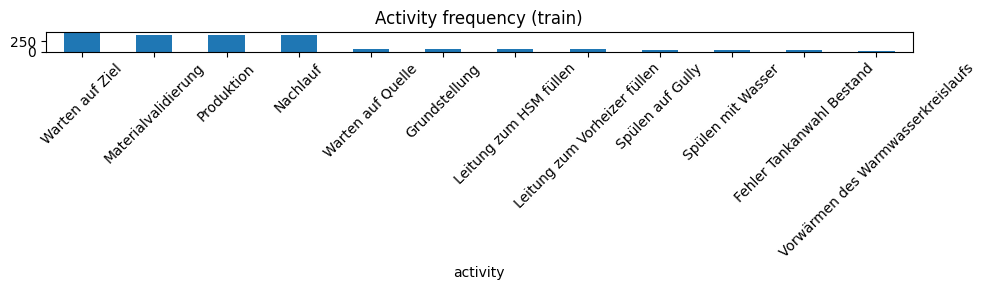

In [93]:
# Activity distribution
act_counts = el_train['activity'].value_counts()
print('Activity counts (train):')
display(act_counts.to_frame('count'))

act_counts.plot(kind='bar', figsize=(10, 3), title='Activity frequency (train)', rot=45)
plt.tight_layout(); plt.show()

In [94]:
# Case-level statistics
case_stats = el_train.groupby('case_id').agg(
    n_events=('activity', 'count'),
    duration_h=('timestamp_start', lambda x: (
        el_train.loc[x.index, 'timestamp_end'].max() - x.min()
    ).total_seconds() / 3600),
    start=('timestamp_start', 'min'),
    activities=('activity', lambda x: list(x.unique()))
)
print(f'Cases in train: {len(case_stats)}')
display(case_stats.describe())

Cases in train: 39


,n_events,duration_h,start
count,39.000000,39.000000,39
mean,51.589744,14.066667,2024-11-10 23:05:41.128205312
min,2.000000,0.134722,2024-11-03 14:03:21
25%,36.500000,7.800000,2024-11-06 19:29:03.500000
50%,60.000000,8.270833,2024-11-11 06:37:01
75%,69.000000,23.812500,2024-11-14 11:39:56
max,77.000000,58.379167,2024-11-19 06:25:21
std,21.443583,12.083640,NaN


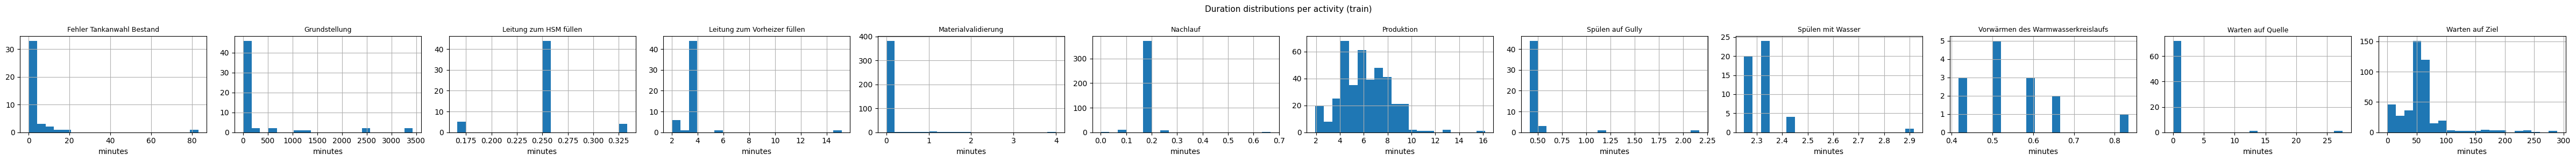

In [95]:
# Per-activity duration distributions
if 'timestamp_end' in el_train.columns:
    el_train['duration_min'] = (el_train['timestamp_end'] - el_train['timestamp_start']).dt.total_seconds() / 60
    n_acts = el_train['activity'].nunique()
    fig, axes = plt.subplots(1, n_acts, figsize=(4 * n_acts, 3), sharey=False)
    if n_acts == 1: axes = [axes]
    for ax, (act, grp) in zip(axes, el_train.groupby('activity')):
        grp['duration_min'].hist(ax=ax, bins=20)
        ax.set_title(act, fontsize=9)
        ax.set_xlabel('minutes')
    plt.suptitle('Duration distributions per activity (train)', fontsize=11)
    plt.tight_layout(); plt.show()

In [96]:
# Directly-follows graph
el_fmt = pm4py.format_dataframe(el_train.dropna(subset=['case_id', 'activity', 'timestamp_start']),
                                 case_id='case_id', activity_key='activity',
                                 timestamp_key='timestamp_start')
dfg, start_acts, end_acts = pm4py.discover_dfg(el_fmt)
print('DFG edges (top 15 by frequency):')
display(pd.Series(dfg).sort_values(ascending=False).head(15).to_frame('freq'))
print('Start activities:', start_acts)
print('End activities:  ', end_acts)

DFG edges (top 15 by frequency):


freq
Nachlauf                     Warten auf Ziel                344
Warten auf Ziel              Materialvalidierung            340
Produktion                   Nachlauf                       333
Materialvalidierung          Produktion                     260
                             Warten auf Quelle               68
Warten auf Quelle            Produktion                      65
Leitung zum HSM füllen       Produktion                      53
Leitung zum Vorheizer füllen Leitung zum HSM füllen          51
Nachlauf                     Spülen auf Gully                49
Spülen mit Wasser            Nachlauf                        49
Produktion                   Spülen mit Wasser               47
Materialvalidierung          Leitung zum Vorheizer füllen    45
Spülen auf Gully             Grundstellung                   30
Fehler Tankanwahl Bestand    Warten auf Ziel                 30
Warten auf Ziel              Fehler Tankanwahl Bestand       27

Start activities: {'Vorwärmen des Warmwasserkreislaufs': 4, 'Materialvalidierung': 29, 'Nachlauf': 4, 'Grundstellung': 2}
End activities:   {'Warten auf Ziel': 29, 'Grundstellung': 3, 'Produktion': 6, 'Fehler Tankanwahl Bestand': 1}


## 4 · Inspect Energy / Expanded Data (ML Input)

This is what `extract_energy_modifiers` / `EnergyProfileExtractor` use as input.

In [97]:
exp_train = pdata_train['expanded']
if exp_train is not None:
    print(f'Expanded train shape: {exp_train.shape}')
    display(exp_train.dtypes.to_frame('dtype'))
    display(exp_train.head(5))
else:
    print('No expanded data for this process.')

Expanded train shape: (1556, 21)


,dtype
datetime_energy,datetime64[ns]
ef_temperature_2m_energy,float32
ef_relative_humidity_2m_energy,float32
ef_global_tilted_irradiance_energy,float32
pro_menge_kg_energy,float64
pro_volstrom_l/h_energy,float64
dampfmenge_kg/h_nmb+cip_energy,float64
pro_power_kW_energy,float64
pro_temp_out_energy,float64
medium_power_kW_energy,float64


,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,ef_global_tilted_irradiance_energy,pro_menge_kg_energy,pro_volstrom_l/h_energy,dampfmenge_kg/h_nmb+cip_energy,pro_power_kW_energy,pro_temp_out_energy,medium_power_kW_energy,...,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,object_type_log,object_log,case_id_log,object_attributes_log,ef_hour_of_day,ef_day_of_week
0,2024-11-03 14:00:00,11.00,75.059265,236.999969,0.0,0.0,106.308387,0.0,30.583709,62.013226,...,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m...",14.0,6.0
1,2024-11-03 14:15:00,11.00,75.059265,236.999985,0.0,0.0,0.000000,0.0,30.647199,0.000000,...,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m...",14.0,6.0
2,2024-11-03 14:30:00,10.65,75.777374,129.000031,0.0,0.0,0.000000,0.0,30.707978,0.000000,...,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m...",14.0,6.0
3,2024-11-03 14:45:00,10.65,75.777374,129.000031,0.0,0.0,590.076839,0.0,30.775373,344.211490,...,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m...",14.0,6.0
4,2024-11-03 15:00:00,10.65,75.777374,129.000031,0.0,0.0,0.383793,0.0,30.844832,0.223879,...,2024-11-03 14:03:21,2024-11-04 08:58:21,Grundstellung,l01,l01,l01,shift_2_2024-11-03,"{'mat_id_m01_': 0, 'mat_id_m02_': 0, 'mat_id_m...",15.0,6.0


In [98]:
# Identify energy / sensor columns
if exp_train is not None:
    numeric_cols = exp_train.select_dtypes(include='number').columns.tolist()
    energy_cols  = [c for c in numeric_cols if 'energy' in c.lower() or 'kW' in c or 'power' in c.lower()]
    print(f'Numeric columns ({len(numeric_cols)}):', numeric_cols[:20], '...' if len(numeric_cols) > 20 else '')
    print(f'\nEnergy/power columns ({len(energy_cols)}):', energy_cols)

Numeric columns (11): ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy', 'ef_hour_of_day', 'ef_day_of_week'] 

Energy/power columns (9): ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy']


In [99]:
# Plot a sensor if configured
if exp_train is not None and ENERGY_SENSOR_COL and ENERGY_SENSOR_COL in exp_train.columns:
    _dt = 'datetime_energy' if 'datetime_energy' in exp_train.columns else exp_train.columns[0]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(pd.to_datetime(exp_train[_dt]), exp_train[ENERGY_SENSOR_COL], lw=0.6, alpha=0.8)
    ax.set_title(f'{ENERGY_SENSOR_COL} — train set'); ax.set_ylabel('value')
    plt.tight_layout(); plt.show()
elif exp_train is not None and energy_cols:
    print(f'Tip: set ENERGY_SENSOR_COL to one of {energy_cols[:5]} to plot the time series.')

Tip: set ENERGY_SENSOR_COL to one of ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'pro_menge_kg_energy', 'pro_volstrom_l/h_energy'] to plot the time series.


In [100]:
# Show columns available as energy features in SimModeller
if exp_train is not None:
    ef_cols = [c for c in exp_train.columns if c.startswith('ef_')]
    print('Energy feature columns (ef_*) that SimModeller will use:')
    display(exp_train[ef_cols].describe() if ef_cols else pd.DataFrame({'note': ['no ef_ columns found']}))

Energy feature columns (ef_*) that SimModeller will use:


,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,ef_global_tilted_irradiance_energy,ef_hour_of_day,ef_day_of_week
count,1556.000000,1556.000000,1556.000000,1556.000000,1556.000000
mean,6.116678,90.347878,36.901672,11.470437,2.802057
std,2.311444,7.597081,68.750435,6.981631,2.092251
min,-0.200000,69.445412,0.000000,0.000000,0.000000
25%,4.550000,84.969872,0.000000,5.000000,1.000000
50%,6.450000,92.642879,0.000000,11.000000,3.000000
75%,7.600000,96.584068,40.000000,18.000000,5.000000
max,11.650000,100.000000,340.999969,23.000000,6.000000


## 5 · Process Discovery (Petri Net Mining)

In [101]:
# Choose mining algorithm for inspection
# (extract_process auto-selects best for energy-aware modes)
MINING_ALGORITHM = "heuristic"   # "alpha" | "heuristic" | "inductive" | "ilp"

print(f"Running extract_process() with {MINING_ALGORITHM} miner ...")
stats_df, raw_df, process_models = extract_process(
    el_train,
    mining_algorithm=MINING_ALGORITHM,
)
print(f"stats_df: {stats_df.shape}  |  raw_df: {raw_df.shape}")
print(f"Extracted {len(process_models)} station model(s):")
for key, entry in process_models.items():
    net = entry["net"]
    print(f"  {key}  |  places={len(net.places)}  transitions={len(net.transitions)}  arcs={len(net.arcs)}")


Running extract_process() with heuristic miner ...

Processing: l01 (1 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 12 unique activities: ['Grundstellung' 'Vorwärmen des Warmwasserkreislaufs' 'Warten auf Ziel'
 'Materialvalidierung' 'Leitung zum Vorheizer füllen'
 'Leitung zum HSM füllen' 'Produktion' 'Spülen mit Wasser' 'Nachlauf'
 'Spülen auf Gully' 'Fehler Tankanwahl Bestand' 'Warten auf Quelle']
    Grundstellung: best fit = weibull_min (0.5902024248363411, 0.0, 167.92275374254805)
    Vorwärmen des Warmwasserkreislaufs: best fit = lognorm (0.15730767326546644, 0.0, 0.6067933719396114)
    Warten auf Ziel: best fit = weibull_min (1.423334222136374, 0.0, 62.167332876925585)
    Materialvalidierung: best fit = norm (0.11954022988505747, 0.15156077935104137)
    Leitung zum Vorheizer füllen: best fit = weibull_min (4.585939635962127, 0.0, 3.492290358791851)
    Leitung zum HSM füllen: best fit = norm (0.24999999999999997, 0.045360921162651446)
    Produktion: 

In [102]:
# Inspect a specific station's model entry
first_key = next(iter(process_models))
entry = process_models[first_key]
print(f'Keys in model entry for {first_key}:')
for k, v in entry.items():
    print(f'  {k}: {type(v).__name__}', end='')
    if isinstance(v, dict):
        print(f'  ({len(v)} keys: {list(v.keys())[:5]})')
    elif isinstance(v, pd.DataFrame):
        print(f'  shape={v.shape}')
    else:
        print()

Keys in model entry for ('l01', 'l01', 'l01'):
  net: PetriNet
  im: Marking  (1 keys: [source0])
  fm: Marking  (1 keys: [sink0])
  stochastic_map: dict  (27 keys: [(hid_4, None), (Vorwärmen des Warmwasserkreislaufs, 'Vorwärmen des Warmwasserkreislaufs'), (Warten auf Ziel, 'Warten auf Ziel'), (hid_24, None), (Materialvalidierung, 'Materialvalidierung')])
  label_stochastic: dict  (12 keys: ['Vorwärmen des Warmwasserkreislaufs', 'Warten auf Ziel', 'Materialvalidierung', 'Leitung zum Vorheizer füllen', 'Leitung zum HSM füllen'])
  duration_map: dict  (12 keys: ['Grundstellung', 'Vorwärmen des Warmwasserkreislaufs', 'Warten auf Ziel', 'Materialvalidierung', 'Leitung zum Vorheizer füllen'])
  mining_hyperparams: dict  (4 keys: ['algorithm', 'noise_threshold', 'heuristic_params', 'optimization_metrics'])
  bigram_transitions: dict  (29 keys: [('__START__', 'Grundstellung'), ('__START__', 'Vorwärmen des Warmwasserkreislaufs'), ('Vorwärmen des Warmwasserkreislaufs', 'Warten auf Ziel'), ('War

In [103]:
# Fitted distributions per activity
if 'distributions' in entry:
    print('Fitted distributions:')
    for act, dist_info in entry['distributions'].items():
        print(f'  {act}: {dist_info}')
elif 'activity_distributions' in entry:
    print('Activity distributions:')
    display(pd.DataFrame(entry['activity_distributions']).T)

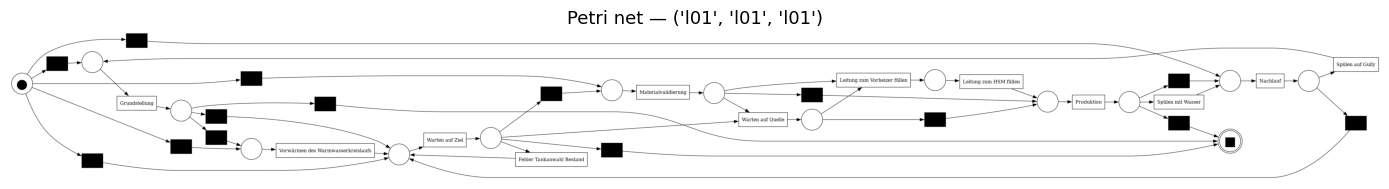

In [104]:
# Visualize Petri nets (real vs simulated placeholder)
import tempfile, matplotlib.image as mpimg
net, im, fm = entry['net'], entry['im'], entry['fm']
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tf:
    tmp_path = tf.name
pm4py.save_vis_petri_net(net, im, fm, tmp_path, bgcolor='white')
img = mpimg.imread(tmp_path)
os.unlink(tmp_path)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img); ax.axis('off'); ax.set_title(f'Petri net — {first_key}', fontsize=13)
plt.tight_layout(); plt.show()

## 6 · ML Features Inspection (SimModeller Input)

In [105]:
# ── What SimModeller trains on ──────────────────────────────────────────────
# raw_df  : one row per activity instance  → actual ML training data
# stats_df: one row per (activity, station) → statistical fallback parameters

# 1. Instantiate (no training yet)
modeller = SimModeller(model_types=ML_MODEL_TYPES, optimize_hyperparams=OPTIMIZE_HYPERPARAMS)

# 2. Show training data shape and sample
print(f"raw_df shape : {raw_df.shape}  (rows=activity instances, cols=features+targets)")
print(f"stats_df shape: {stats_df.shape}  (rows=unique activity keys)")

# 3. Show exact feature columns SimModeller will select
feature_cols = SimModeller._feature_cols(raw_df)
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# 4. Show regression and classification targets
print(f"Regression target  — duration (minutes):")
display(raw_df["duration"].describe().round(2).to_frame("duration").T)

print(f"Classification target — next_activity:")
display(raw_df["next_activity"].value_counts().to_frame("count"))

# 5. Per-activity breakdown: how many rows does each activity have?
print("Per-activity training rows:")
display(
    raw_df.groupby("activity").agg(
        n_instances=("duration", "count"),
        mean_duration_min=("duration", "mean"),
        std_duration_min=("duration", "std"),
        next_activities=("next_activity", lambda x: list(x.unique())),
    ).round(2)
)

# 6. Show a sample of the raw feature matrix
print("Sample rows (features + targets):")
display(raw_df[feature_cols + ["duration", "next_activity"]].head(10))


raw_df shape : (2012, 18)  (rows=activity instances, cols=features+targets)
stats_df shape: (24, 12)  (rows=unique activity keys)
Feature columns (7): ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
Regression target  — duration (minutes):


,count,mean,std,min,25%,50%,75%,max
duration,2012.0,23.1,143.74,0.0,0.17,1.04,9.0,3431.83


Classification target — next_activity:


,count
next_activity,
Warten auf Ziel,440
Produktion,394
Nachlauf,389
Materialvalidierung,334
__END__,77
Warten auf Quelle,74
Leitung zum HSM füllen,53
Leitung zum Vorheizer füllen,53
Grundstellung,53


Per-activity training rows:


,n_instances,mean_duration_min,std_duration_min,next_activities
activity,,,,
Fehler Tankanwahl Bestand,41,4.36,13.18,"[Warten auf Ziel, Grundstellung, Materialvalid..."
Grundstellung,56,319.68,794.14,"[__END__, Vorwärmen des Warmwasserkreislaufs, ..."
Leitung zum HSM füllen,53,0.25,0.03,[Produktion]
Leitung zum Vorheizer füllen,53,3.62,1.70,[Leitung zum HSM füllen]
Materialvalidierung,395,0.11,0.28,"[Leitung zum Vorheizer füllen, Produktion, War..."
Nachlauf,393,0.17,0.03,"[Spülen auf Gully, Warten auf Ziel]"
Produktion,394,6.04,2.03,"[Spülen mit Wasser, Nachlauf, __END__, Materia..."
Spülen auf Gully,49,0.53,0.26,[Grundstellung]
Spülen mit Wasser,49,2.32,0.10,[Nachlauf]


Sample rows (features + targets):


,attr_mat_id_m01_,attr_mat_id_m02_,attr_mat_id_m03_,prev_activity_1,prev_duration_1,prev_activity_2,prev_duration_2,duration,next_activity
0,0,0,0,__NONE__,0.000000,__NONE__,0.000000,1135.000000,__END__
1,8681982,0,0,Spülen auf Gully,0.416667,Nachlauf,0.166667,34.666667,Vorwärmen des Warmwasserkreislaufs
2,0,8681588,8681588,Spülen auf Gully,0.416667,Nachlauf,0.166667,51.750000,Warten auf Ziel
3,8681588,8681588,8681588,Spülen auf Gully,0.500000,Nachlauf,0.166667,45.916667,Warten auf Ziel
4,0,8681588,8681588,Spülen auf Gully,0.416667,Nachlauf,0.166667,42.916667,Warten auf Ziel
5,8681588,0,8681588,Spülen auf Gully,0.416667,Nachlauf,0.166667,44.666667,Warten auf Ziel
6,0,8681588,8681588,Spülen auf Gully,0.500000,Nachlauf,0.166667,44.333333,Warten auf Ziel
7,0,8681588,8681588,Spülen auf Gully,0.500000,Nachlauf,0.166667,41.500000,Warten auf Ziel
8,0,8681588,8681588,Spülen auf Gully,0.500000,Nachlauf,0.166667,40.583333,Vorwärmen des Warmwasserkreislaufs
9,8681588,8681588,8681588,Spülen auf Gully,0.500000,Nachlauf,0.166667,43.500000,Warten auf Ziel


In [106]:
# ── Feature columns used by SimModeller, broken down per activity ────────────
#
# Feature types:
#   attr_*        — process/object attributes attached to the event (e.g. product type,
#                   machine id). These come from the event log, NOT from sensor readings.
#   prev_activity_1/2 — the activity that ran 1 or 2 steps before this one (lag window).
#   prev_duration_1/2 — how long those previous activities took, in minutes.
#
# NOTE: sensor / energy columns are NOT used here. They are only used in the
#       separate energy modifier models (Section 7b), not in SimModeller.
#
feature_cols = SimModeller._feature_cols(raw_df)

# Separate numeric vs categorical features for the right aggregation
_numeric_feats = [c for c in feature_cols if pd.api.types.is_numeric_dtype(raw_df[c])]
_cat_feats     = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(raw_df[c])]

print('── Feature columns passed to every activity model ──')
print('Numeric features:', _numeric_feats if _numeric_feats else '(none)')
print('Categorical features:', _cat_feats if _cat_feats else '(none)')
print()

# Build per-activity table: mean for numeric, top-value for categorical
_parts = [raw_df.groupby('activity').agg(n_instances=('duration', 'count'))]

if _numeric_feats:
    _parts.append(
        raw_df.groupby('activity')[_numeric_feats].mean().round(3)
        .rename(columns={c: f'{c} (mean)' for c in _numeric_feats})
    )

if _cat_feats:
    for c in _cat_feats:
        _mode = raw_df.groupby('activity')[c].agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
        _nuniq = raw_df.groupby('activity')[c].nunique()
        _parts.append(_mode.rename(f'{c} (top value)'))
        _parts.append(_nuniq.rename(f'{c} (n unique values)'))

feat_table = pd.concat(_parts, axis=1).sort_values('n_instances', ascending=False)

print('Per-activity feature summary (before training):')
with pd.option_context('display.max_colwidth', 40, 'display.max_columns', 30):
    display(feat_table)


── Feature columns passed to every activity model ──
Numeric features: ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_duration_1', 'prev_duration_2']
Categorical features: ['prev_activity_1', 'prev_activity_2']

Per-activity feature summary (before training):


,n_instances,attr_mat_id_m01_ (mean),attr_mat_id_m02_ (mean),attr_mat_id_m03_ (mean),prev_duration_1 (mean),prev_duration_2 (mean),prev_activity_1 (top value),prev_activity_1 (n unique values),prev_activity_2 (top value),prev_activity_2 (n unique values)
activity,,,,,,,,,,
Warten auf Ziel,441,6181465.079,5846791.605,4901855.855,4.340,11.169,Nachlauf,7,Produktion,8
Materialvalidierung,395,6351863.015,6198003.185,5252918.544,48.365,4.209,Warten auf Ziel,5,Nachlauf,8
Produktion,394,6345949.454,6279837.629,5200147.076,0.211,37.664,Materialvalidierung,3,Warten auf Ziel,7
Nachlauf,393,6229553.522,6229545.186,5102926.214,7.541,0.726,Produktion,5,Materialvalidierung,7
Warten auf Quelle,74,6452557.297,5983269.014,5044720.351,0.812,44.716,Materialvalidierung,2,Warten auf Ziel,4
Grundstellung,56,5115955.821,5425997.643,6046115.500,6.699,2.850,Spülen auf Gully,5,Nachlauf,5
Leitung zum HSM füllen,53,6060767.396,4586504.528,4586505.170,3.616,0.086,Leitung zum Vorheizer füllen,1,Materialvalidierung,2
Leitung zum Vorheizer füllen,53,6060767.396,4586504.528,4586505.170,0.086,19.484,Materialvalidierung,2,Warten auf Ziel,3
Spülen mit Wasser,49,5138105.510,6023964.898,6732671.020,4.481,0.347,Produktion,1,Materialvalidierung,3


Categorical features label-encoded for correlation: ['prev_activity_1', 'prev_activity_2']

Feature correlation with activity label (ranked by |r|):


,corr_with_activity
prev_activity_1,-0.482
prev_duration_1,-0.242
prev_activity_2,0.171
prev_duration_2,0.111
attr_mat_id_m03_,-0.023
attr_mat_id_m01_,-0.011
attr_mat_id_m02_,0.010


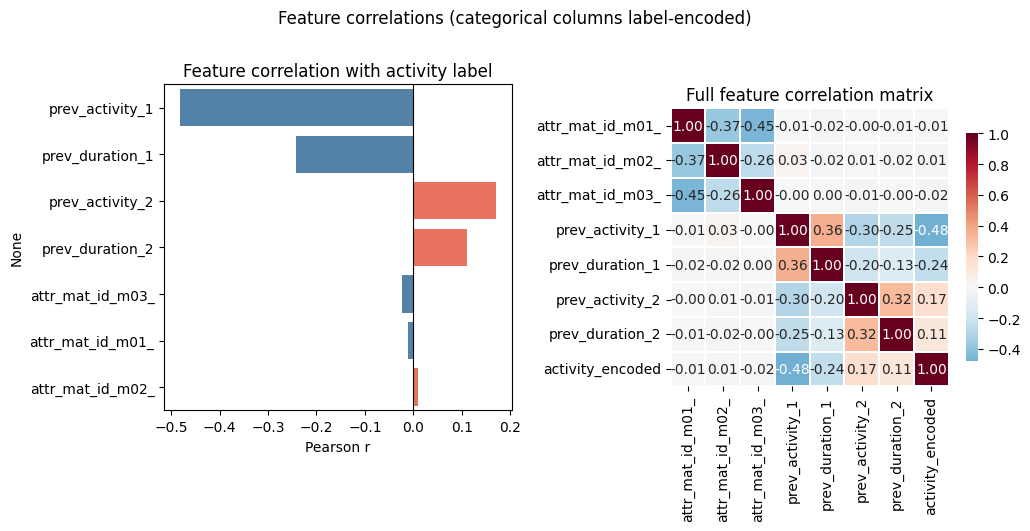

In [107]:
# ── Correlation between activity label and all features ──────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

feature_cols = SimModeller._feature_cols(raw_df)

feat_df = raw_df[feature_cols + ['duration', 'activity']].copy()

# Encode activity as integer
le_act = LabelEncoder()
feat_df['activity_encoded'] = le_act.fit_transform(feat_df['activity'])

# Encode any categorical feature columns
encoded_names = {}
for col in feature_cols:
    if feat_df[col].dtype == object or str(feat_df[col].dtype) == 'category':
        le = LabelEncoder()
        feat_df[col] = le.fit_transform(feat_df[col].fillna('__NA__').astype(str))
        encoded_names[col] = True
    else:
        feat_df[col] = pd.to_numeric(feat_df[col], errors='coerce')

if encoded_names:
    print(f'Categorical features label-encoded for correlation: {list(encoded_names)}')

corr_cols = feature_cols + ['activity_encoded']
corr = feat_df[corr_cols].corr()

# Ranked bar of feature correlation with activity
act_corr = corr['activity_encoded'].drop('activity_encoded').sort_values(key=abs, ascending=False)
print('\nFeature correlation with activity label (ranked by |r|):')
display(act_corr.to_frame('corr_with_activity').round(3))

# Full feature-vs-feature + activity heatmap
n_cols = len(corr_cols)
fig, axes = plt.subplots(1, 2, figsize=(max(10, n_cols * 0.8 + 4), max(5, n_cols * 0.5)))

# Left: heatmap of corr of all features with activity
sns.barplot(
    y=act_corr.index, x=act_corr.values, ax=axes[0],
    palette=['tomato' if v > 0 else 'steelblue' for v in act_corr.values],
    orient='h'
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature correlation with activity label')
axes[0].set_xlabel('Pearson r')

# Right: full pairwise heatmap
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    ax=axes[1], square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
axes[1].set_title('Full feature correlation matrix')

plt.suptitle('Feature correlations (categorical columns label-encoded)', y=1.01)
plt.tight_layout()
plt.show()


## 7 · Train Simulation Models

In [65]:
print(f"Training SimModeller ({ML_MODEL_TYPES}) on {PROCESS_NAME} train set ...")
# SimModeller.train() takes (raw_df, stats_df) — both come from extract_process()
modeller.train(
    raw_df=raw_df,
    stats_df=stats_df,
)
print("SimModeller training complete.")


Training SimModeller (['xgboost']) on process_2 train set ...

[SimModeller] Model types      : ['xgboost']
[SimModeller] Optuna tuning    : False
[SimModeller] Internal val %   : 20%
[SimModeller] Feature columns  : ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']

  Key: ('Fehler Tankanwahl Bestand', 'l01', 'l01', 'l01')
    Fit size: 17, Val size: 5, Total: 22
    Duration [ xgboost]  MAE=2.625  RMSE=4.499  R²=-115.393
    ✓ Best duration model: xgboost  (val MAE=2.625)
    Transition [ xgboost]  Acc=1.000  F1=1.000
    ✓ Best transition model: xgboost  (val Acc=1.000)

  Key: ('Fehler Tankanwahl Bestand', 'l02', 'l02', 'l02')
    Fit size: 15, Val size: 4, Total: 19
    Duration [ xgboost]  MAE=2.681  RMSE=4.385  R²=-55.882
    ✓ Best duration model: xgboost  (val MAE=2.681)
    Transition [ xgboost]  Acc=1.000  F1=1.000
    ✓ Best transition model: xgboost  (val Acc=1.000)

  Key: ('Grundstellu

In [66]:
# Inspect per-activity models
# duration_models[key] = (model, feature_cols, model_type)
# metrics are in duration_val_metrics[key]

if modeller.duration_models:
    print(f"Duration models trained: {len(modeller.duration_models)}")
    for key, (mdl, feat_cols, mtype) in list(modeller.duration_models.items())[:6]:
        metrics = modeller.duration_val_metrics.get(key, {})
        print(f"  {key}")
        print(f"    model_type={mtype}  features={feat_cols}")
        if metrics:
            mae = metrics.get("mae")
            r2 = metrics.get("r2")

            if mae is not None and r2 is not None:
                print(f"    val_mae={mae:.4f}  val_r2={r2:.4f}")
            else:
                print(f"    val_mae={mae}  val_r2={r2}")

if modeller.transition_models:
    print(f"Transition models trained: {len(modeller.transition_models)}")
    for key, (mdl, le, feat_cols, mtype) in list(modeller.transition_models.items())[:6]:
        metrics = modeller.transition_val_metrics.get(key, {})
        print(f"  {key}")
        print(f"    model_type={mtype}  classes={list(le.classes_)[:5]}")
        if metrics:
            accuracy = metrics.get("accuracy")
            f1 = metrics.get("f1")

            if accuracy is not None and f1 is not None:
                print(f"    val_acc={accuracy:.4f}  val_f1={f1:.4f}")
            else:
                print(f"    val_acc={accuracy}  val_f1={f1}")

Duration models trained: 24
  ('Fehler Tankanwahl Bestand', 'l01', 'l01', 'l01')
    model_type=xgboost  features=['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=2.6253  val_r2=-115.3926
  ('Fehler Tankanwahl Bestand', 'l02', 'l02', 'l02')
    model_type=xgboost  features=['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=2.6807  val_r2=-55.8823
  ('Grundstellung', 'l01', 'l01', 'l01')
    model_type=xgboost  features=['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duration_2']
    val_mae=690.6534  val_r2=-0.2601
  ('Grundstellung', 'l02', 'l02', 'l02')
    model_type=xgboost  features=['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'prev_activity_1', 'prev_duration_1', 'prev_activity_2', 'prev_duratio

In [67]:
# ── Post-training: per-activity model summary ────────────────────────────────
# Shows which model type was selected for each activity, its features, and validation metrics.

rows = []
all_activities = raw_df['activity'].unique()

for act in sorted(all_activities):
    n_inst = int((raw_df['activity'] == act).sum())

    # Duration model — key could be (process, activity) tuple or plain string
    dur_key = next((k for k in modeller.duration_models if (k[-1] if isinstance(k, tuple) else k) == act), None)
    if dur_key is not None:
        _, dur_feat_cols, dur_mtype = modeller.duration_models[dur_key]
        dur_m = modeller.duration_val_metrics.get(dur_key, {})
        dur_mae = round(dur_m.get('mae', float('nan')), 3)
        dur_r2 = round(dur_m.get('r2', float('nan')), 3)
    else:
        dur_feat_cols, dur_mtype, dur_mae, dur_r2 = [], 'not trained', None, None

    # Transition model
    tr_key = next((k for k in modeller.transition_models if (k[-1] if isinstance(k, tuple) else k) == act), None)
    if tr_key is not None:
        _, _, tr_feat_cols, tr_mtype = modeller.transition_models[tr_key]
        tr_m = modeller.transition_val_metrics.get(tr_key, {})
        tr_acc = round(tr_m.get('accuracy', float('nan')), 3)
        tr_f1 = round(tr_m.get('f1', float('nan')), 3)
    else:
        tr_feat_cols, tr_mtype, tr_acc, tr_f1 = [], 'not trained', None, None

    rows.append({
        'activity': act,
        'n_instances': n_inst,
        'dur_model': dur_mtype,
        'dur_features': ', '.join(dur_feat_cols) if dur_feat_cols else '—',
        'dur_val_mae': dur_mae,
        'dur_val_r2': dur_r2,
        'tr_model': tr_mtype,
        'tr_features': ', '.join(tr_feat_cols) if tr_feat_cols else '—',
        'tr_val_acc': tr_acc,
        'tr_val_f1': tr_f1,
    })

summary_df = pd.DataFrame(rows).set_index('activity')
print(f'Training summary — {len(modeller.duration_models)} duration models, '
      f'{len(modeller.transition_models)} transition models')

# Wide display so feature names are fully visible
with pd.option_context('display.max_colwidth', 200):
    display(summary_df)


Training summary — 24 duration models, 13 transition models


,n_instances,dur_model,dur_features,dur_val_mae,dur_val_r2,tr_model,tr_features,tr_val_acc,tr_val_f1
activity,,,,,,,,,
Fehler Tankanwahl Bestand,41,not trained,—,None,None,not trained,—,None,None
Grundstellung,56,not trained,—,None,None,not trained,—,None,None
Leitung zum HSM füllen,53,not trained,—,None,None,not trained,—,None,None
Leitung zum Vorheizer füllen,53,not trained,—,None,None,not trained,—,None,None
Materialvalidierung,395,not trained,—,None,None,not trained,—,None,None
Nachlauf,393,not trained,—,None,None,not trained,—,None,None
Produktion,394,not trained,—,None,None,not trained,—,None,None
Spülen auf Gully,49,not trained,—,None,None,not trained,—,None,None
Spülen mit Wasser,49,not trained,—,None,None,not trained,—,None,None


## 7b · Energy Modifier Models (for petri_net_energy_* modes)

These are **separate** from SimModeller. They are only needed when
 is one of the  variants.

Feature inputs per activity instance:
- **6 per sensor**: , , , , ,  over the activity window
- **1 per ef_col**:  over the window

Two families:
-  — learns a **multiplicative correction** on top of statistical base
-  — ML **directly predicts** duration / next activity


In [68]:
# Identify sensor columns in expanded data
_ENERGY_MODES = {
    "petri_net_energy_aware", "petri_net_energy_duration_aware",
    "petri_net_energy_transition_aware", "petri_net_energy_direct",
    "petri_net_energy_direct_duration_only", "petri_net_energy_direct_transition_only",
    "petri_net_energy_dist", "petri_net_direct_test",
    "petri_net_quantile_blend", "petri_net_blend_duration", "petri_net_test_2",
}

if exp_train is not None:
    sensor_cols = [c for c in exp_train.columns
                   if c.endswith("_energy") and c in exp_train.select_dtypes("number").columns]
    ef_cols     = [c for c in exp_train.columns if c.startswith("ef_")]
    print(f"Sensor columns ({len(sensor_cols)}): {sensor_cols}")
    print(f"EF columns     ({len(ef_cols)}):     {ef_cols}")
    print(f"For mode={SIMULATION_MODE!r}: needs energy models = {SIMULATION_MODE in _ENERGY_MODES}")
else:
    sensor_cols = []
    ef_cols = []
    print("No expanded data — energy models cannot be trained.")


Sensor columns (9): ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy']
EF columns     (5):     ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'ef_hour_of_day', 'ef_day_of_week']
For mode='petri_net_inductive': needs energy models = False


In [69]:
# Diagnose what columns exp_train has vs what extract_energy_modifiers expects
print("All exp_train columns:")
display(pd.DataFrame({"column": exp_train.columns, "dtype": exp_train.dtypes.values}))

# Required columns for _build_energy_state_matrix
required = ["activity_log", "timestamp_start_log", "timestamp_end_log",
            "case_id_log", "object_log", "datetime_energy"]
print("Required column  → found in exp_train?")
for c in required:
    print(f"  {c:30} : {c in exp_train.columns}")

# Suggest mappings for missing columns
print("Columns that might map to the required ones:")
for kw in ["activity", "timestamp", "case", "object"]:
    matches = [c for c in exp_train.columns if kw in c.lower()]
    print(f"  *{kw}* : {matches}")

# Separate true process sensors from external factors (ef_*)
sensor_cols_clean = [c for c in exp_train.columns
                     if c.endswith("_energy")
                     and not c.startswith("ef_")
                     and c in exp_train.select_dtypes("number").columns]
ef_cols_clean     = [c for c in exp_train.columns
                     if c.startswith("ef_") and c in exp_train.select_dtypes("number").columns]
print(f"Process sensors (no ef_ prefix, ends _energy): {sensor_cols_clean}")
print(f"External factors (ef_* numeric):               {ef_cols_clean}")


All exp_train columns:


,column,dtype
0,datetime_energy,datetime64[ns]
1,ef_temperature_2m_energy,float32
2,ef_relative_humidity_2m_energy,float32
3,ef_global_tilted_irradiance_energy,float32
4,pro_menge_kg_energy,float64
5,pro_volstrom_l/h_energy,float64
6,dampfmenge_kg/h_nmb+cip_energy,float64
7,pro_power_kW_energy,float64
8,pro_temp_out_energy,float64
9,medium_power_kW_energy,float64


Required column  → found in exp_train?
  activity_log                   : True
  timestamp_start_log            : True
  timestamp_end_log              : True
  case_id_log                    : True
  object_log                     : True
  datetime_energy                : True
Columns that might map to the required ones:
  *activity* : ['activity_log', 'higher_level_activity_log']
  *timestamp* : ['timestamp_start_log', 'timestamp_end_log']
  *case* : ['case_id_log']
  *object* : ['object_type_log', 'object_log', 'object_attributes_log']
Process sensors (no ef_ prefix, ends _energy): ['pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy']
External factors (ef_* numeric):               ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'ef_hour_of_day', 'ef_day_of_week']


In [70]:
# Detect column name mapping (activity_log vs activity, etc.)
_act_col = "activity_log"       if "activity_log"       in exp_train.columns else "activity"
_ts_col  = "timestamp_start_log" if "timestamp_start_log" in exp_train.columns else "timestamp_start"
_dt_col  = "datetime_energy"    if "datetime_energy"    in exp_train.columns else exp_train.columns[0]

SENSORS_TO_USE = sensor_cols_clean  # process energy sensors only (no ef_ prefix)

energy_duration_modifiers   = {}
energy_transition_modifiers = {}
energy_direct_duration      = {}
energy_direct_transition    = {}
energy_state_columns        = []
modifier_report             = {}
direct_report               = {}

if SENSORS_TO_USE:
    print(f"Activity column  : {_act_col}")
    print(f"Timestamp column : {_ts_col}")
    print(f"Datetime column  : {_dt_col}")
    print(f"Process sensors  : {SENSORS_TO_USE}")
    print(f"External factors : {ef_cols_clean}")
    print()

    print("Training energy MODIFIER models ...")
    energy_duration_modifiers, energy_transition_modifiers, energy_state_columns, modifier_report = \
        extract_energy_modifiers(
            df_expanded=exp_train,
            sensors=SENSORS_TO_USE,
            activity_col=_act_col,
            timestamp_start_col=_ts_col,
            datetime_energy_col=_dt_col,
            ef_cols=ef_cols_clean if ef_cols_clean else None,
        )
    print(f"  duration modifiers  : {len(energy_duration_modifiers)}")
    print(f"  transition modifiers: {len(energy_transition_modifiers)}")

    print("\nTraining energy DIRECT models ...")
    energy_direct_duration, energy_direct_transition, _, direct_report = \
        extract_energy_direct_models(
            df_expanded=exp_train,
            sensors=SENSORS_TO_USE,
            activity_col=_act_col,
            timestamp_start_col=_ts_col,
            datetime_energy_col=_dt_col,
            ef_cols=ef_cols_clean if ef_cols_clean else None,
        )
    print(f"  direct duration models  : {len(energy_direct_duration)}")
    print(f"  direct transition models: {len(energy_direct_transition)}")

    # ── Full coverage table: every activity, whether ML or stat or skipped ──
    all_activities = sorted(stats_df["activity"].dropna().unique())
    print(f"\n=== Activity coverage ({len(all_activities)} activities) ===")
    rows = []
    for act in all_activities:
        act_str  = str(act)
        n_inst   = int((raw_df["activity"] == act).sum()) if "activity" in raw_df.columns else "?"
        skipped  = "not modelled (no valid energy windows or ML did not beat baseline)"
        in_mod   = act_str in modifier_report
        in_dir   = act_str in direct_report
        rows.append({
            "activity"   : act_str,
            "n_instances": n_inst,
            "Modifier Duration" : modifier_report[act_str].get("Duration Approach",  skipped) if in_mod else skipped,
            "Modifier Transition": modifier_report[act_str].get("Transition Approach",skipped) if in_mod else skipped,
            "Direct Duration"   : direct_report[act_str].get("Duration Approach",    skipped) if in_dir else skipped,
            "Direct Transition" : direct_report[act_str].get("Transition Approach",  skipped) if in_dir else skipped,
        })
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 80):
        display(pd.DataFrame(rows).set_index("activity"))
else:
    print("No process sensor columns found. Check exp_train columns in the diagnostic cell.")


Activity column  : activity_log
Timestamp column : timestamp_start_log
Datetime column  : datetime_energy
Process sensors  : ['pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy']
External factors : ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'ef_hour_of_day', 'ef_day_of_week']

Training energy MODIFIER models ...

ENERGY MODIFIER EXTRACTION
  Sensors          : ['pro_menge_kg_energy', 'pro_volstrom_l/h_energy', 'dampfmenge_kg/h_nmb+cip_energy', 'pro_power_kW_energy', 'pro_temp_out_energy', 'medium_power_kW_energy']
  Duration models  : None
  Transition models: None
  External factors : ['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy', 'ef_global_tilted_irradiance_energy', 'ef_hour_of_day', 'ef_day_of_week']
  Total instances  : 214
  [Warten auf Ziel] Duration -> statistical (best ML CV MAE=0.243 ≥ baseline 0.234)


,n_instances,Modifier Duration,Modifier Transition,Direct Duration,Direct Transition
activity,,,,,
Fehler Tankanwahl Bestand,41,Statistical Base Method (n=1<30),Statistical Base Method (n=1<30),Statistical (n=1<30),Statistical (n=1<30)
Grundstellung,56,Statistical Base Method (n=27<30),Statistical Base Method (n=27<30),Statistical (n=27<30),Statistical (n=27<30)
Leitung zum HSM füllen,53,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Leitung zum Vorheizer füllen,53,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Materialvalidierung,395,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Nachlauf,393,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Produktion,394,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Spülen auf Gully,49,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)
Spülen mit Wasser,49,not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline),not modelled (no valid energy windows or ML did not beat baseline)


## 8 · Run Simulation

In [71]:
n_cases = N_CASES_TO_SIMULATE or el_test["case_id"].nunique()
print(f"Running simulation: mode={SIMULATION_MODE}  cases={n_cases}")

pp_test = pdata_test["production_plan"]
pp_sim  = pp_test.head(n_cases) if len(pp_test) >= n_cases else pp_test

simulator = ProcessSimulation(
    activity_stats_df=stats_df,
    production_plan=pp_sim,
    mode=SIMULATION_MODE,
    ml_models=modeller,
    process_models=process_models,
    # energy modifier models (used by petri_net_energy_* modes)
    energy_duration_modifiers=energy_duration_modifiers   or None,
    energy_transition_modifiers=energy_transition_modifiers or None,
    energy_state_columns=energy_state_columns              or None,
)
simulated_log = simulator.run()
print(f"Simulated log shape: {simulated_log.shape}")
display(simulated_log.head(5))


Running simulation: mode=petri_net_inductive  cases=10
[DEBUG __init__] mode=petri_net_inductive, process_models is None: False, process_models len: 2
Building config from 24 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.03571428571428571, 'Vorwärmen des Warmwasserkreislaufs': 0.14285714285714285, 'Warten auf Ziel': 0.6785714285714286, '__END__': 0.14285714285714285}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09954751131221719, 'Grundstellung': 0.004524886877828055, 'Materialvalidierung': 0.7420814479638009, 'Warten auf Quelle': 0.00904977375565611, '__END__': 0.14479638009049775}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11794871794871795, 'Produktion': 0.702564

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,shift_2_2024-11-19,Grundstellung,2024-11-19 15:11:06.000000,2024-11-19 15:57:42.007203,l01,l01,l01,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
1,shift_2_2024-11-19,Grundstellung,2024-11-19 15:57:42.007203,2024-11-19 18:36:44.712381,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
2,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 18:36:45.712381,2024-11-19 18:58:08.165225,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
3,shift_2_2024-11-19,Fehler Tankanwahl Bestand,2024-11-19 18:58:09.165225,2024-11-19 19:08:20.983766,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
4,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 19:08:21.983766,2024-11-19 20:11:20.317233,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."


In [72]:
# Quick sanity check: activity counts comparison
_comparison = pd.DataFrame({
    'real':      el_test['activity'].value_counts(),
    'simulated': simulated_log['activity'].value_counts() if 'activity' in simulated_log.columns else 0,
}).fillna(0)
display(_comparison)

,real,simulated
activity,,
Fehler Tankanwahl Bestand,10,6
Grundstellung,19,19
Leitung zum HSM füllen,16,11
Leitung zum Vorheizer füllen,16,11
Materialvalidierung,111,58
Nachlauf,111,64
Produktion,111,58
Spülen auf Gully,18,10
Spülen mit Wasser,18,7


## 9 · Evaluate Simulation

In [73]:
eval_results = comprehensive_simulation_evaluation(
    simulated_df=simulated_log,
    real_df=el_test,
    process_models=process_models,
    verbose=True,
)

COMPREHENSIVE SIMULATION EVALUATION

1. BASIC PROCESS METRICS
Events — Real: 575, Sim: 340, Ratio: 0.591
Cases  — Real: 10,  Sim: 10,  Ratio: 1.000

2. ACTIVITY FREQUENCY ANALYSIS
JS Divergence (activities): 0.0676
Freq MAE: 0.0117

3. DURATION ANALYSIS
           Real  Simulated  Error
Mean     25.657     25.927  0.011
Median    0.667      2.404  2.607
Std     179.446    114.619  0.361
KS=0.2243  p=0.0000  |  act-dur-err=0.5248  |  JS-whole=0.2289  JS-activ=0.6451

4. CASE-LEVEL ANALYSIS
         Real  Simulated  Error
Mean    57.50     34.000  0.409
Median  53.00     26.000  0.509
Std     20.25     25.162  0.243

5. CONTROL-FLOW ANALYSIS (DFG)
Edges — Real: 31, Sim: 27, Common: 21
EdgeF1=0.7241  StartJaccard=0.1667  EndJaccard=0.6667

6. CLASSIC PM CONFORMANCE

7. OVERALL QUALITY SCORE
Overall error: 0.5378  (POOR)


In [74]:
# Flatten results into a DataFrame for easy inspection
flat = {}
for section, metrics in eval_results.items():
    if isinstance(metrics, dict):
        for metric_name, value in metrics.items():
            flat[f'{section}_{metric_name}'] = value
    elif not isinstance(metrics, str):
        flat[section] = metrics

results_series = pd.Series(flat).sort_index()
display(results_series.to_frame('value'))

,value
activity_metrics_activity_coverage_ratio,1.000000e+00
activity_metrics_frequency_mae,1.168372e-02
activity_metrics_js_divergence,8.757167e-02
basic_metrics_case_count_error,0.000000e+00
basic_metrics_case_count_ratio,1.000000e+00
basic_metrics_event_count_error,6.468750e-01
basic_metrics_event_count_ratio,1.646875e+00
case_metrics_events_per_case_ks,6.000000e-01
case_metrics_events_per_case_pvalue,5.244755e-02
case_metrics_mean_events_per_case_error,4.086957e-01


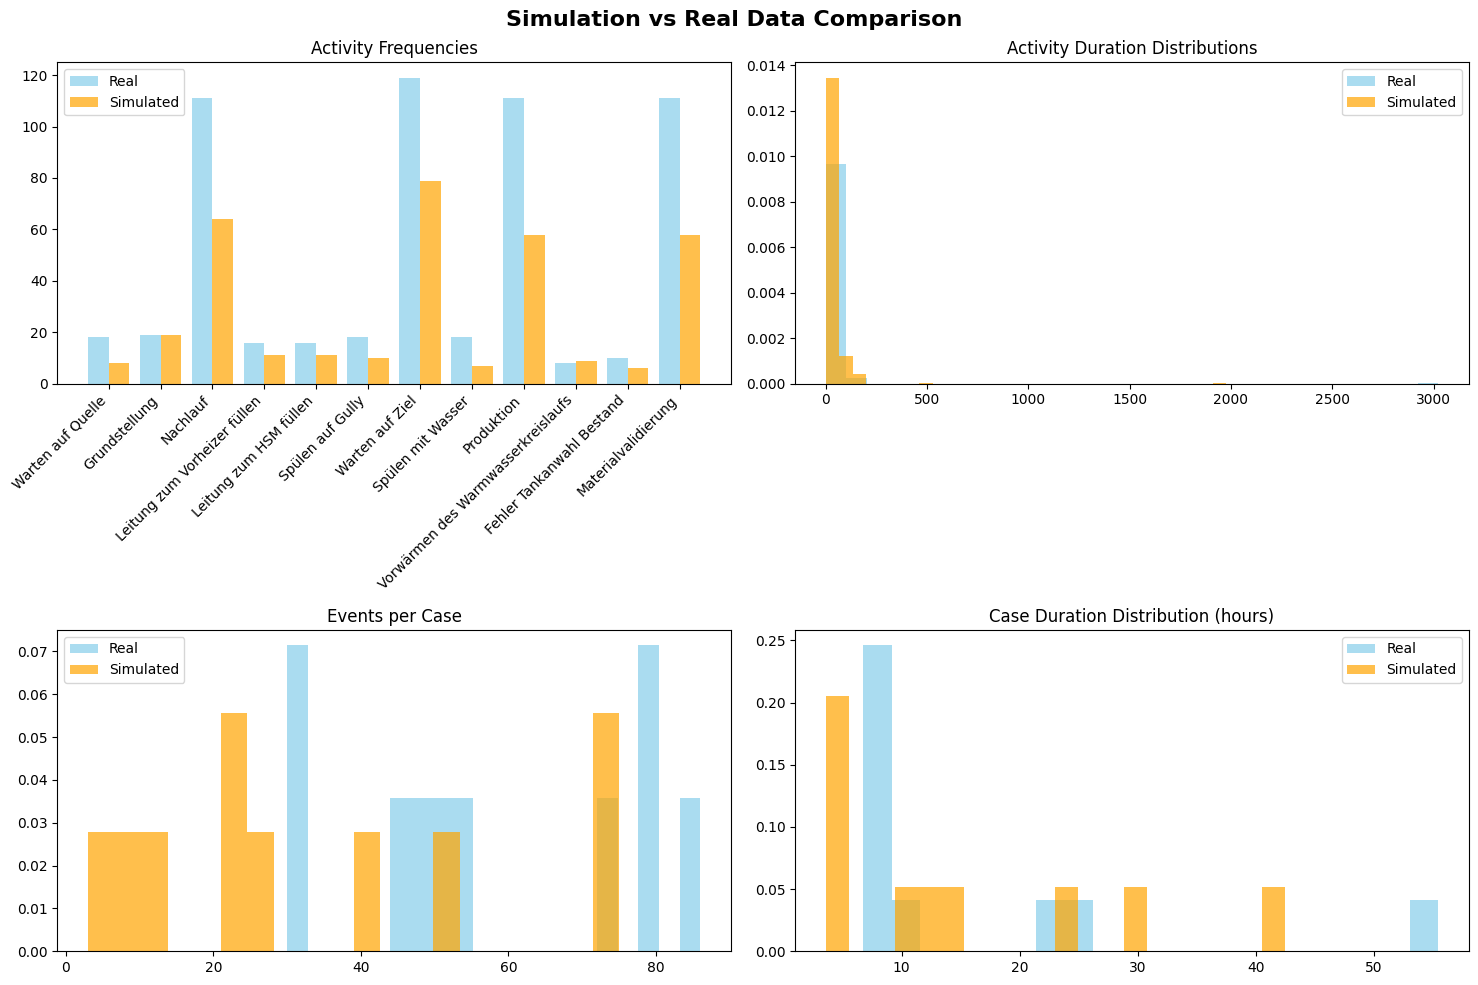

In [75]:
plot_simulation_comparison(simulated_log, el_test)

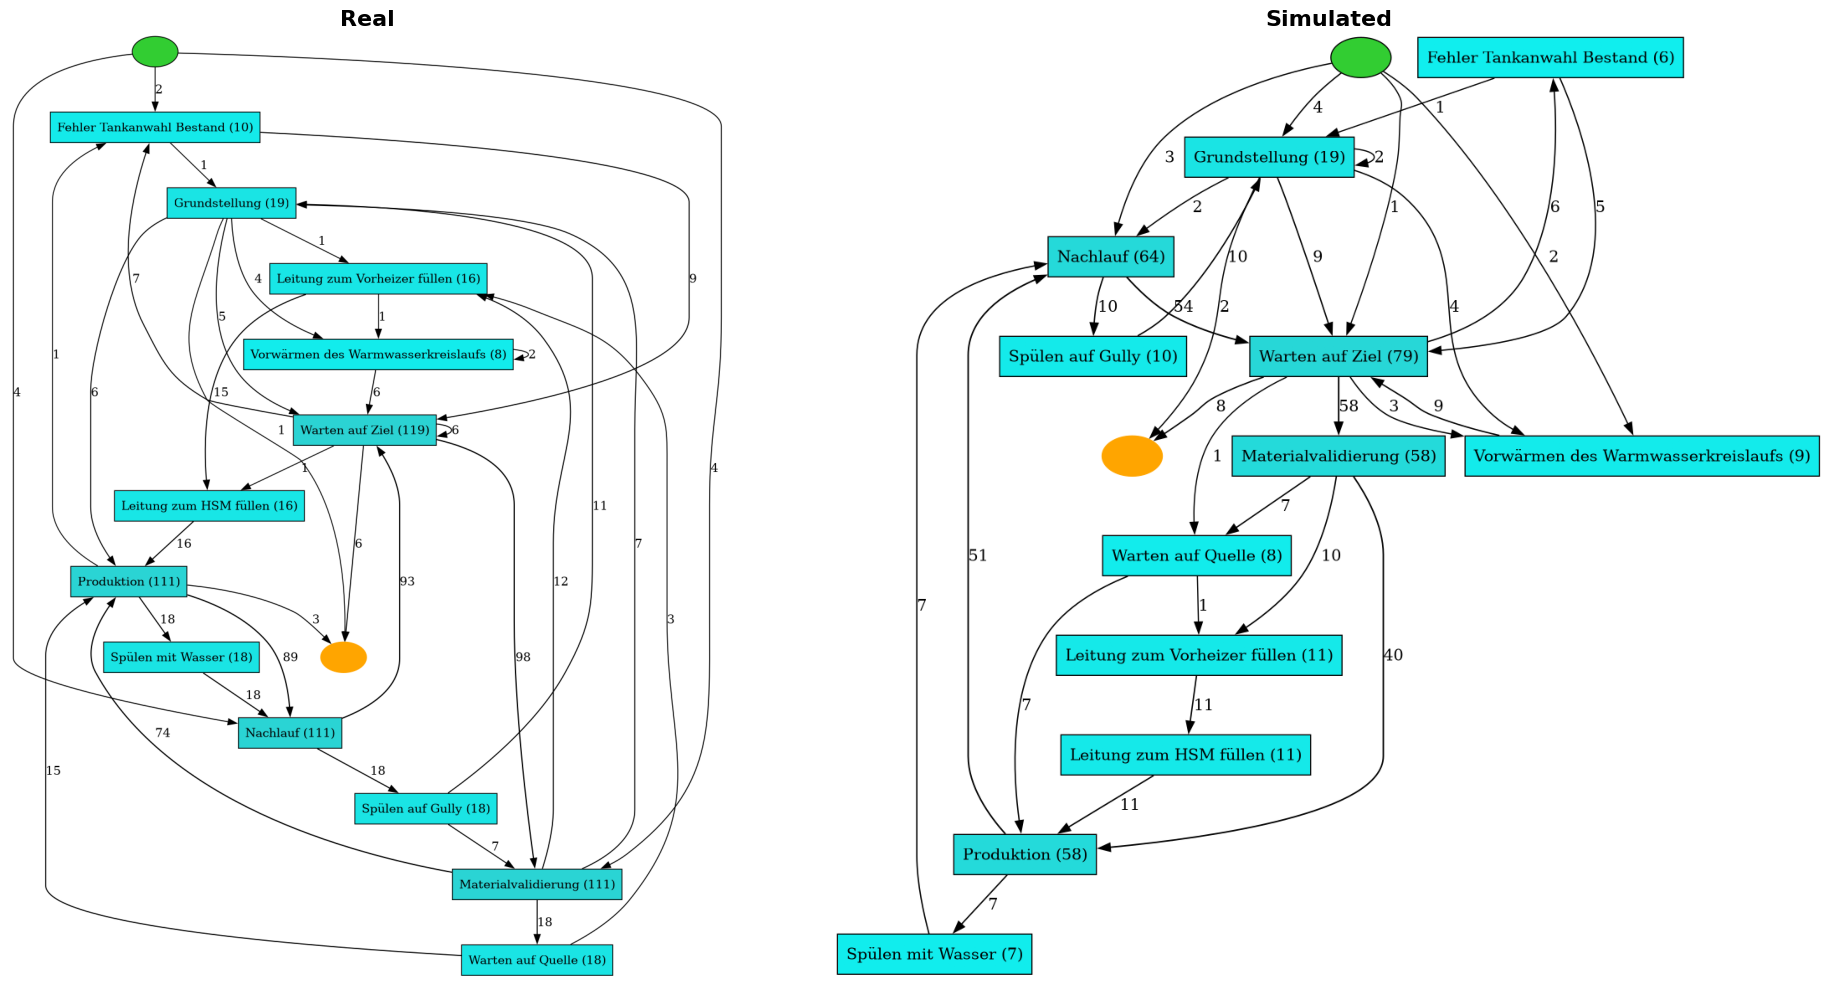

In [76]:
visualize_heuristic_nets(el_test, simulated_log)

## 10 · Compare Multiple Modes

Run several modes and produce a heatmap — same logic as the full pipeline but interactive.

In [77]:
n_cases = N_CASES_TO_SIMULATE or el_test["case_id"].nunique()
print(f"Running simulation: mode={SIMULATION_MODE}  cases={n_cases}")

pp_test = pdata_test["production_plan"]
pp_sim  = pp_test.head(n_cases) if len(pp_test) >= n_cases else pp_test

simulator = ProcessSimulation(
    activity_stats_df=stats_df,
    production_plan=pp_sim,
    mode=SIMULATION_MODE,
    ml_models=modeller,
    process_models=process_models,
    # energy modifier models (used by petri_net_energy_* modes)
    energy_duration_modifiers=energy_duration_modifiers   or None,
    energy_transition_modifiers=energy_transition_modifiers or None,
    energy_state_columns=energy_state_columns              or None,
)
simulated_log = simulator.run()
print(f"Simulated log shape: {simulated_log.shape}")
display(simulated_log.head(5))


Running simulation: mode=petri_net_inductive  cases=10
[DEBUG __init__] mode=petri_net_inductive, process_models is None: False, process_models len: 2
Building config from 24 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.03571428571428571, 'Vorwärmen des Warmwasserkreislaufs': 0.14285714285714285, 'Warten auf Ziel': 0.6785714285714286, '__END__': 0.14285714285714285}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09954751131221719, 'Grundstellung': 0.004524886877828055, 'Materialvalidierung': 0.7420814479638009, 'Warten auf Quelle': 0.00904977375565611, '__END__': 0.14479638009049775}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11794871794871795, 'Produktion': 0.702564

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,shift_2_2024-11-19,Grundstellung,2024-11-19 15:11:06.000000,2024-11-19 15:57:42.007203,l01,l01,l01,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
1,shift_2_2024-11-19,Grundstellung,2024-11-19 15:57:42.007203,2024-11-19 18:36:44.712381,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
2,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 18:36:45.712381,2024-11-19 18:58:08.165225,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
3,shift_2_2024-11-19,Fehler Tankanwahl Bestand,2024-11-19 18:58:09.165225,2024-11-19 19:08:20.983766,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
4,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 19:08:21.983766,2024-11-19 20:11:20.317233,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."


In [78]:
n_cases = N_CASES_TO_SIMULATE or el_test["case_id"].nunique()
print(f"Running simulation: mode={SIMULATION_MODE}  cases={n_cases}")

pp_test = pdata_test["production_plan"]
pp_sim  = pp_test.head(n_cases) if len(pp_test) >= n_cases else pp_test

simulator = ProcessSimulation(
    activity_stats_df=stats_df,
    production_plan=pp_sim,
    mode=SIMULATION_MODE,
    ml_models=modeller,
    process_models=process_models,
    # energy modifier models (used by petri_net_energy_* modes)
    energy_duration_modifiers=energy_duration_modifiers   or None,
    energy_transition_modifiers=energy_transition_modifiers or None,
    energy_state_columns=energy_state_columns              or None,
)
simulated_log = simulator.run()
print(f"Simulated log shape: {simulated_log.shape}")
display(simulated_log.head(5))


Running simulation: mode=petri_net_inductive  cases=10
[DEBUG __init__] mode=petri_net_inductive, process_models is None: False, process_models len: 2
Building config from 24 activities:
  Config: ('Grundstellung', 'l01', 'l01', 'l01')
    Transitions: {'Nachlauf': 0.03571428571428571, 'Vorwärmen des Warmwasserkreislaufs': 0.14285714285714285, 'Warten auf Ziel': 0.6785714285714286, '__END__': 0.14285714285714285}
    Start: True
  Config: ('Vorwärmen des Warmwasserkreislaufs', 'l01', 'l01', 'l01')
    Transitions: {'Warten auf Ziel': 1.0}
    Start: True
  Config: ('Warten auf Ziel', 'l01', 'l01', 'l01')
    Transitions: {'Fehler Tankanwahl Bestand': 0.09954751131221719, 'Grundstellung': 0.004524886877828055, 'Materialvalidierung': 0.7420814479638009, 'Warten auf Quelle': 0.00904977375565611, '__END__': 0.14479638009049775}
    Start: True
  Config: ('Materialvalidierung', 'l01', 'l01', 'l01')
    Transitions: {'Leitung zum Vorheizer füllen': 0.11794871794871795, 'Produktion': 0.702564

,case_id,activity,timestamp_start,timestamp_end,object,object_type,higher_level_activity,object_attributes
0,shift_2_2024-11-19,Grundstellung,2024-11-19 15:11:06.000000,2024-11-19 15:57:42.007203,l01,l01,l01,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
1,shift_2_2024-11-19,Grundstellung,2024-11-19 15:57:42.007203,2024-11-19 18:36:44.712381,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
2,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 18:36:45.712381,2024-11-19 18:58:08.165225,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
3,shift_2_2024-11-19,Fehler Tankanwahl Bestand,2024-11-19 18:58:09.165225,2024-11-19 19:08:20.983766,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."
4,shift_2_2024-11-19,Warten auf Ziel,2024-11-19 19:08:21.983766,2024-11-19 20:11:20.317233,l02,l02,l02,"{'mat_id_m01_': 8681607, 'mat_id_m02_': 0, 'ma..."


In [79]:
try:
    evaluation_results_df
except NameError:
    print("Run the multi-mode loop cell above first.")
else:
    if not evaluation_results_df.empty:
        _plot_short_heatmap(evaluation_results_df,
                            f"{PROCESS_NAME} — mode comparison",
                            split="test")
    else:
        print("No results collected — check the loop cell above.")


Run the multi-mode loop cell above first.


## 11 · Energy Profile Extraction

Inspect the input data and train `EnergyProfileExtractor`.
Set `ENERGY_SENSOR_COL` in the Config cell above to activate.

In [80]:
if ENERGY_SENSOR_COL is None:
    print('ENERGY_SENSOR_COL is None — skipping energy section.')
    print('Set it to a column name in the expanded DataFrame (see Section 4).')
else:
    print(f'Energy sensor: {ENERGY_SENSOR_COL}')

ENERGY_SENSOR_COL is None — skipping energy section.
Set it to a column name in the expanded DataFrame (see Section 4).


In [81]:
# Show what EnergyProfileExtractor receives as input
if ENERGY_SENSOR_COL and exp_train is not None:
    _required_cols = ["case_id", "activity", "start_end", "datetime_energy", ENERGY_SENSOR_COL]
    _avail = [c for c in _required_cols if c in exp_train.columns]
    print(f"Columns available: {_avail}")
    print(f"Columns needed but missing: {set(_required_cols) - set(_avail)}")
    display(exp_train[_avail].head(10))


In [82]:
if ENERGY_SENSOR_COL and exp_train is not None and ENERGY_SENSOR_COL in exp_train.columns:
    extractor = EnergyProfileExtractor(
        value_column=ENERGY_SENSOR_COL,
        case_id_column='case_id',
        activity_column='activity',
        start_end_column='start_end',
        timestamp_column='datetime_energy',
        verbose=True,
    )
    results_df = extractor.fit(exp_train)
    print('\nModel performance:')
    display(results_df)

In [83]:
if ENERGY_SENSOR_COL and exp_train is not None and ENERGY_SENSOR_COL in exp_train.columns:
    # Predict curves for each activity and compare to extracted real curves
    activities = exp_train['activity'].dropna().unique()
    n_a = len(activities)
    fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 3))
    if n_a == 1: axes = [axes]

    for ax, act in zip(axes, activities):
        # Plot a sample of real curves
        real_curves = [c['values'] for c in extractor.curves_ if c['activity'] == act]
        for rc in real_curves[:5]:
            ax.plot(np.linspace(0, 1, len(rc)), rc, color='skyblue', alpha=0.4, lw=0.8)
        # Plot predicted curve (median output_length)
        if real_curves:
            median_len = int(np.median([len(c) for c in real_curves]))
            pred = extractor.predict_curve(activity=act, output_length=median_len)
            ax.plot(np.linspace(0, 1, len(pred)), pred, color='red', lw=1.5, label='predicted')
        ax.set_title(act, fontsize=9); ax.legend(fontsize=7)

    plt.suptitle(f'{ENERGY_SENSOR_COL} — real curves (blue) vs predicted (red)', fontsize=11)
    plt.tight_layout(); plt.show()

## 12 · Debug Helpers

Utility cells for drilling into specific cases or activities.

In [84]:
# Drill into a specific case: real vs simulated trace
CASE_TO_INSPECT = el_test["case_id"].iloc[0]  # change this

real_case = el_test[el_test["case_id"] == CASE_TO_INSPECT].sort_values("timestamp_start").copy()
real_case["duration_min"] = (real_case["timestamp_end"] - real_case["timestamp_start"]).dt.total_seconds() / 60

sim_case = (
    simulated_log[simulated_log["case_id"] == CASE_TO_INSPECT].sort_values("timestamp_start")
    if "case_id" in simulated_log.columns else pd.DataFrame()
)

print(f"=== Case {CASE_TO_INSPECT} ===")
print(f"Real trace ({len(real_case)} events):")
display(real_case[["activity", "timestamp_start", "timestamp_end", "duration_min"]].head(20))

if not sim_case.empty:
    print(f"Simulated case ({len(sim_case)} events):")
    display(sim_case[["activity", "timestamp_start", "timestamp_end"]].head(20))
else:
    print(f"No simulated case found for case_id={CASE_TO_INSPECT!r}")
    print("Available simulated case_ids:", simulated_log["case_id"].unique()[:10] if "case_id" in simulated_log.columns else "none")


=== Case shift_2_2024-11-19 ===
Real trace (72 events):


,activity,timestamp_start,timestamp_end,duration_min
2292,Nachlauf,2024-11-19 14:07:11,2024-11-19 14:07:21,0.166667
2293,Warten auf Ziel,2024-11-19 14:07:26,2024-11-19 15:00:51,53.416667
997,Materialvalidierung,2024-11-19 14:11:06,2024-11-19 14:11:11,0.083333
998,Produktion,2024-11-19 14:11:16,2024-11-19 14:16:26,5.166667
999,Nachlauf,2024-11-19 14:16:31,2024-11-19 14:16:41,0.166667
1000,Warten auf Ziel,2024-11-19 14:16:46,2024-11-19 16:02:36,105.833333
2294,Materialvalidierung,2024-11-19 15:00:56,2024-11-19 15:01:01,0.083333
2295,Produktion,2024-11-19 15:01:06,2024-11-19 15:11:36,10.500000
2296,Nachlauf,2024-11-19 15:11:41,2024-11-19 15:11:51,0.166667
2297,Warten auf Ziel,2024-11-19 15:11:56,2024-11-19 15:43:26,31.500000


Simulated case (41 events):


,activity,timestamp_start,timestamp_end
0,Grundstellung,2024-11-19 15:11:06.000000,2024-11-19 15:57:42.007203
1,Grundstellung,2024-11-19 15:57:42.007203,2024-11-19 18:36:44.712381
2,Warten auf Ziel,2024-11-19 18:36:45.712381,2024-11-19 18:58:08.165225
3,Fehler Tankanwahl Bestand,2024-11-19 18:58:09.165225,2024-11-19 19:08:20.983766
4,Warten auf Ziel,2024-11-19 19:08:21.983766,2024-11-19 20:11:20.317233
5,Materialvalidierung,2024-11-19 20:11:21.317233,2024-11-19 20:11:27.317233
6,Warten auf Quelle,2024-11-19 20:11:28.317233,2024-11-19 20:15:25.938024
7,Produktion,2024-11-19 20:15:26.938024,2024-11-19 20:22:23.249089
8,Nachlauf,2024-11-19 20:22:24.249089,2024-11-19 20:22:34.618098
9,Warten auf Ziel,2024-11-19 20:22:35.618098,2024-11-19 20:56:12.122538


Activity: Grundstellung  |  n=56
Best distribution: lognorm  params=(1.5543685812615304, 0.0, 63.861394033370836)


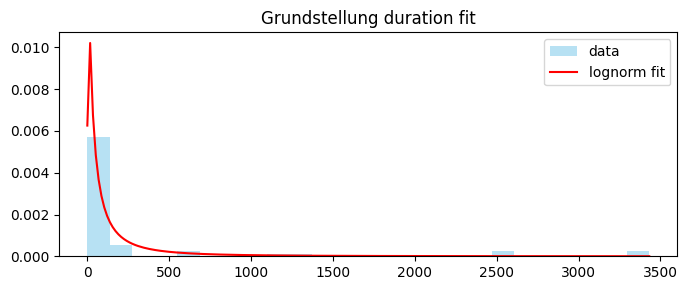

In [85]:
# Drill into a specific activity's duration fit
ACTIVITY_TO_INSPECT = el_train['activity'].iloc[0]  # change this

act_data = el_train[el_train['activity'] == ACTIVITY_TO_INSPECT]
if 'duration_min' not in act_data.columns:
    act_data = act_data.copy()
    act_data['duration_min'] = (act_data['timestamp_end'] - act_data['timestamp_start']).dt.total_seconds() / 60

durations = act_data['duration_min'].dropna().values
dist_name, dist_params = fit_best_distribution(durations)

print(f'Activity: {ACTIVITY_TO_INSPECT}  |  n={len(durations)}')
print(f'Best distribution: {dist_name}  params={dist_params}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(durations, bins=25, density=True, alpha=0.6, color='skyblue', label='data')
x = np.linspace(durations.min(), durations.max(), 200)
from scipy import stats as scipy_stats
dist_obj = getattr(scipy_stats, dist_name)
ax.plot(x, dist_obj.pdf(x, *dist_params), 'r-', lw=1.5, label=f'{dist_name} fit')
ax.set_title(f'{ACTIVITY_TO_INSPECT} duration fit'); ax.legend()
plt.tight_layout(); plt.show()

In [86]:
# Show transition probabilities from the Petri net token replay
for key, entry in process_models.items():
    if 'transition_probs' in entry:
        print(f'Transition probs — {key}:')
        for act, probs in list(entry['transition_probs'].items())[:5]:
            print(f'  {act}: {dict(sorted(probs.items(), key=lambda x: -x[1])[:5])}')
    elif 'next_activity_probs' in entry:
        print(f'Next-activity probs — {key}:')
        display(pd.DataFrame(entry['next_activity_probs']))